<a href="https://colab.research.google.com/github/np03cs4a230349-stack/AI-ML/blob/main/2408983_Abhiral_Pradhan_code_PartB_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import time
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, Activation
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: []


In [ ]:
import shutil
import os

SOURCE_FOLDER = "/content/drive/MyDrive/AI-ML/Portfolio/facial expression classification"
DEST_FOLDER = "/content/facial_expression_dataset"

# Remove old copied folder if it already exists
if os.path.exists(DEST_FOLDER):
    shutil.rmtree(DEST_FOLDER)

# Copy folder from Drive to /content
shutil.copytree(SOURCE_FOLDER, DEST_FOLDER)

print("Folder copied successfully!")
print("Copied to:", DEST_FOLDER)
print("Folders inside:", os.listdir(DEST_FOLDER))

Folder copied successfully!
Copied to: /content/facial_expression_dataset
Folders inside: ['validation', 'train', 'test']


In [ ]:
train_dir = "/content/facial_expression_dataset/train"
val_dir   = "/content/facial_expression_dataset/validation"
test_dir  = "/content/facial_expression_dataset/test"

# ── MobileNetV2 needs minimum 96x96 RGB ──
# Part A used 64x64 grayscale — here we upscale slightly and convert to RGB
IMG_SIZE   = 96
BATCH_SIZE = 32

CLASS_NAMES = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
NUM_CLASSES = 7

print("Paths configured.")
print(f"Images will be resized to ({IMG_SIZE}, {IMG_SIZE}) RGB for MobileNetV2")

Paths configured.
Images will be resized to (96, 96) RGB for MobileNetV2


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# ── color_mode='rgb' converts your greyscale images to 3-channel ──
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb'
)

validation_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

print(f"Training samples   : {train_generator.samples:,}")
print(f"Validation samples : {validation_generator.samples:,}")
print(f"Test samples       : {test_generator.samples:,}")
print(f"Class indices      : {train_generator.class_indices}")

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Training samples   : 26,872
Validation samples : 7,066
Test samples       : 1,900
Class indices      : {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.0414696535152315), 1: np.float64(11.668258792878854), 2: np.float64(1.0112900797832305), 3: np.float64(0.559844996770766), 4: np.float64(0.8211459129106188), 5: np.float64(0.8289477743159454), 6: np.float64(1.3246573991915607)}


In [ ]:
# Load MobileNetV2 WITHOUT its top classification layer ──
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,      # removes the ImageNet 1000-class head
    weights='imagenet'      # pre-trained on ImageNet
)

#  PHASE 1: Freeze the entire base
base_model.trainable = False

#  Add custom classification head (matching Part A FC layers)
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(128)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

# Compile
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

# Count params
total     = transfer_model.count_params()
trainable = sum(tf.keras.backend.count_params(w) for w in transfer_model.trainable_weights)
print(f"\nTotal params     : {total:,}")
print(f"Trainable params : {trainable:,}  ← only the new head")
print(f"Frozen params    : {total - trainable:,}  ← MobileNetV2 base")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,621,255 (10.00 MB)

 Trainable params: 362,503 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)


Total params     : 2,621,255
Trainable params : 362,503  ← only the new head
Frozen params    : 2,258,752  ← MobileNetV2 base


In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("PHASE 1: Feature Extraction (base frozen)")

phase1_start = time.time()

phase1_history = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weights
)

phase1_time = time.time() - phase1_start
print(f"\nPhase 1 complete in {phase1_time/60:.1f} min")
print(f"Best val accuracy: {max(phase1_history.history['val_accuracy']):.4f}")

PHASE 1: Feature Extraction (base frozen)
Epoch 1/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 382s 443ms/step - accuracy: 0.2130 - loss: 2.0598 - val_accuracy: 0.3288 - val_loss: 1.7185
Epoch 2/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 355s 422ms/step - accuracy: 0.2705 - loss: 1.8598 - val_accuracy: 0.3629 - val_loss: 1.6544
Epoch 3/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 357s 425ms/step - accuracy: 0.3009 - loss: 1.7861 - val_accuracy: 0.3714 - val_loss: 1.6195
Epoch 4/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 352s 419ms/step - accuracy: 0.3153 - loss: 1.7235 - val_accuracy: 0.3902 - val_loss: 1.5842
Epoch 5/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 358s 426ms/step - accuracy: 0.3295 - loss: 1.6864 - val_accuracy: 0.4106 - val_loss: 1.5454
Epoch 6/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 361s 430ms/step - accuracy: 0.3443 - loss: 1.6639 - val_accuracy: 0.3995 - val_loss: 1.5599
Epoch 7/20
840/840 ━━━━━━━━━━━━━━━━━━━━ 384s 457ms/step - accuracy: 0.3430 - loss: 1.6350 - val_accuracy: 0.4040 - val_loss: 1.5473
Epoch 8/20
840/840 ━━━━━━━━━━━━━━━

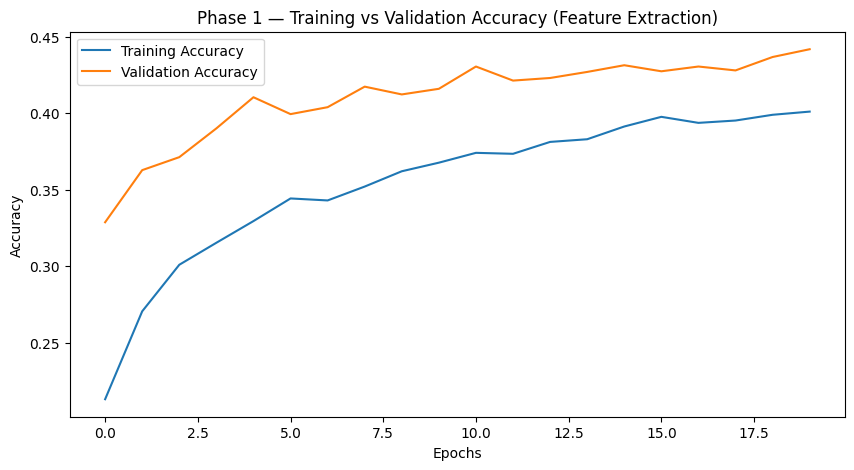

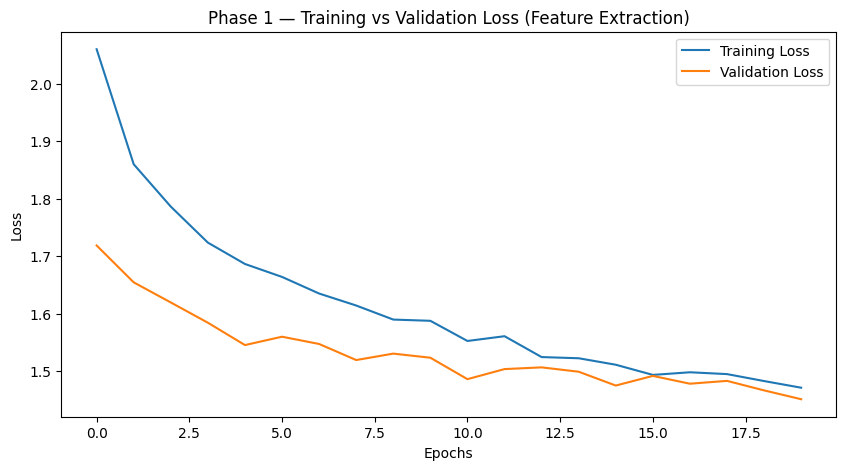

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(phase1_history.history['accuracy'], label='Training Accuracy')
plt.plot(phase1_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Phase 1 — Training vs Validation Accuracy (Feature Extraction)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(phase1_history.history['loss'], label='Training Loss')
plt.plot(phase1_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Phase 1 — Training vs Validation Loss (Feature Extraction)')
plt.legend()
plt.show()

In [ ]:
# ── Unfreeze the top 30 layers of MobileNetV2 ──
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# ── Recompile with a lower learning rate ──
transfer_model.compile(
    optimizer=Adam(learning_rate=0.00001),   # 10x lower than Phase 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

trainable_now = sum(tf.keras.backend.count_params(w) for w in transfer_model.trainable_weights)
print(f"Trainable params after unfreezing top 30 layers: {trainable_now:,}")

early_stopping_ft = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

print("PHASE 2: Fine-Tuning (top 30 layers unfrozen)")

phase2_start = time.time()

phase2_history = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stopping_ft],
    class_weight=class_weights
)

phase2_time = time.time() - phase2_start
print(f"\nPhase 2 complete in {phase2_time/60:.1f} min")
print(f"Best val accuracy: {max(phase2_history.history['val_accuracy']):.4f}")
print(f"Total training time: {(phase1_time + phase2_time)/60:.1f} min")

Trainable params after unfreezing top 30 layers: 1,888,903
PHASE 2: Fine-Tuning (top 30 layers unfrozen)
Epoch 1/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 518s 597ms/step - accuracy: 0.3112 - loss: 1.7339 - val_accuracy: 0.3835 - val_loss: 1.6285
Epoch 2/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 501s 596ms/step - accuracy: 0.3441 - loss: 1.6252 - val_accuracy: 0.4012 - val_loss: 1.5492
Epoch 3/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 494s 588ms/step - accuracy: 0.3616 - loss: 1.5696 - val_accuracy: 0.4121 - val_loss: 1.5186
Epoch 4/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 519s 618ms/step - accuracy: 0.3817 - loss: 1.5185 - val_accuracy: 0.4247 - val_loss: 1.4858
Epoch 5/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 498s 592ms/step - accuracy: 0.3939 - loss: 1.4892 - val_accuracy: 0.4239 - val_loss: 1.4945
Epoch 6/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 500s 590ms/step - accuracy: 0.4025 - loss: 1.4629 - val_accuracy: 0.4233 - val_loss: 1.4874
Epoch 7/30
840/840 ━━━━━━━━━━━━━━━━━━━━ 496s 591ms/step - accuracy: 0.4139 - loss: 1.4234 - val_accurac

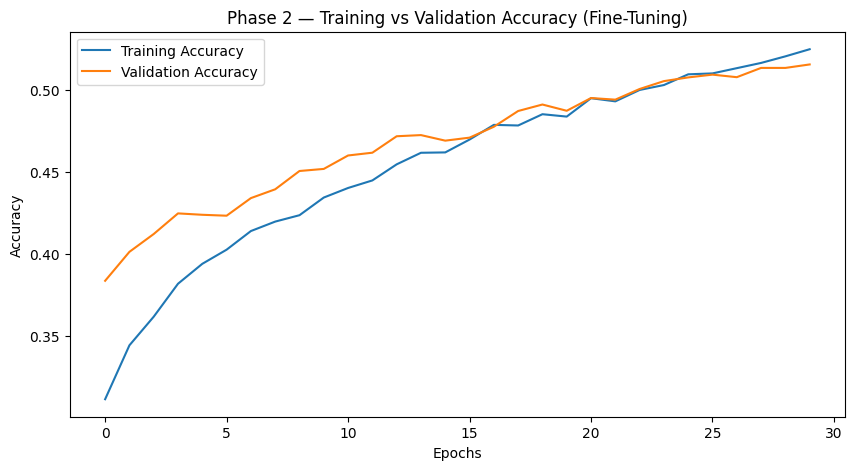

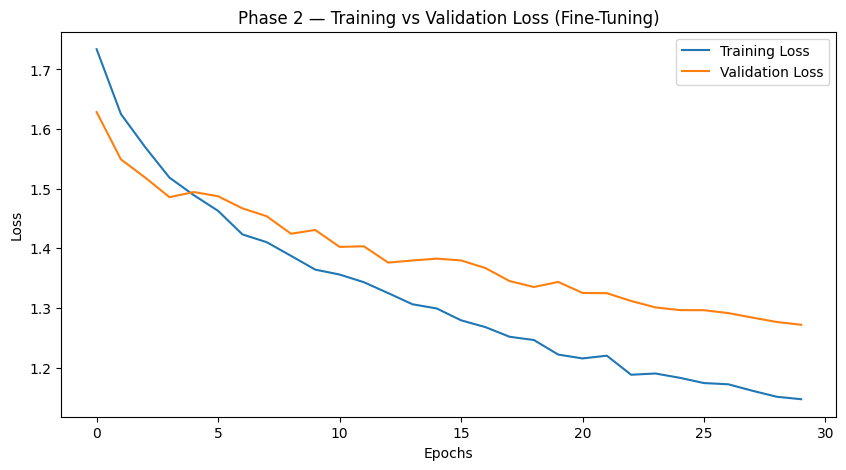

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(phase2_history.history['accuracy'], label='Training Accuracy')
plt.plot(phase2_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Phase 2 — Training vs Validation Accuracy (Fine-Tuning)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(phase2_history.history['loss'], label='Training Loss')
plt.plot(phase2_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Phase 2 — Training vs Validation Loss (Fine-Tuning)')
plt.legend()
plt.show()

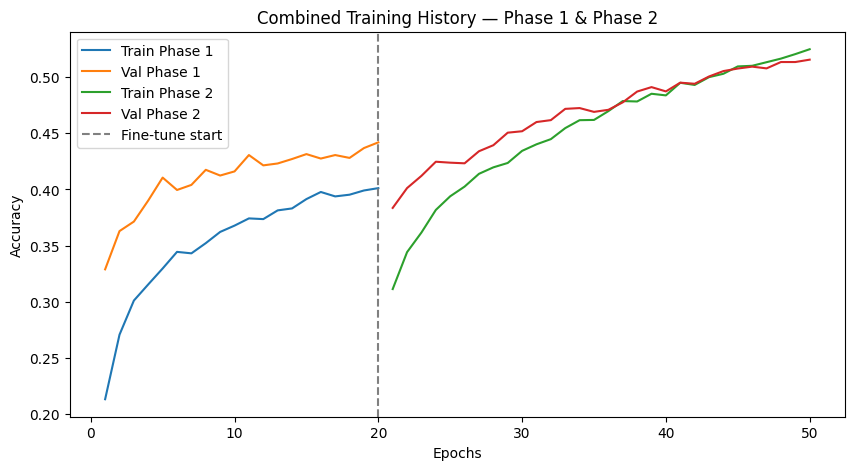

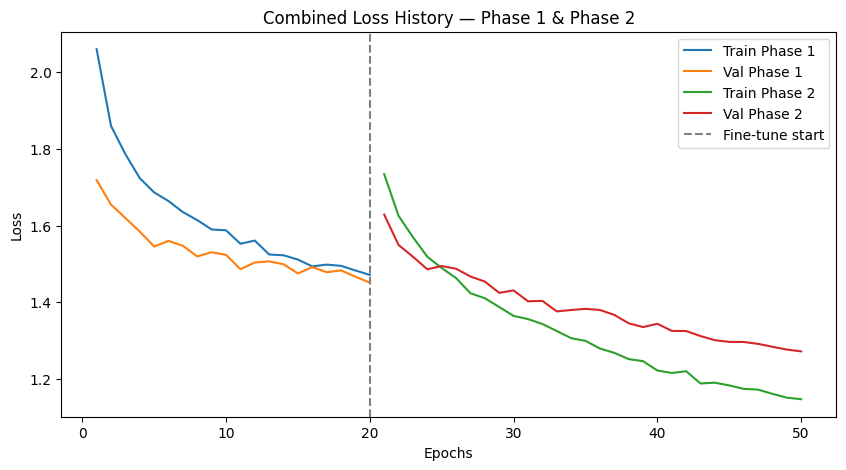

In [ ]:
a1  = phase1_history.history['accuracy']
va1 = phase1_history.history['val_accuracy']
l1  = phase1_history.history['loss']
vl1 = phase1_history.history['val_loss']

a2  = phase2_history.history['accuracy']
va2 = phase2_history.history['val_accuracy']
l2  = phase2_history.history['loss']
vl2 = phase2_history.history['val_loss']

e1 = range(1, len(a1) + 1)
e2 = range(len(a1) + 1, len(a1) + len(a2) + 1)

plt.figure(figsize=(10, 5))
plt.plot(e1, a1,  label='Train Phase 1')
plt.plot(e1, va1, label='Val Phase 1')
plt.plot(e2, a2,  label='Train Phase 2')
plt.plot(e2, va2, label='Val Phase 2')
plt.axvline(x=len(a1), color='grey', linestyle='--', label='Fine-tune start')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Combined Training History — Phase 1 & Phase 2')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(e1, l1,  label='Train Phase 1')
plt.plot(e1, vl1, label='Val Phase 1')
plt.plot(e2, l2,  label='Train Phase 2')
plt.plot(e2, vl2, label='Val Phase 2')
plt.axvline(x=len(a1), color='grey', linestyle='--', label='Fine-tune start')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Combined Loss History — Phase 1 & Phase 2')
plt.legend()
plt.show()

In [ ]:
import numpy as np

predictions = transfer_model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 322ms/step
              precision    recall  f1-score   support

       angry       0.46      0.34      0.39       300
     disgust       0.44      0.58      0.50       100
        fear       0.50      0.19      0.28       300
       happy       0.65      0.68      0.67       300
     neutral       0.41      0.57      0.48       300
         sad       0.35      0.48      0.40       300
    surprise       0.68      0.67      0.67       300

    accuracy                           0.49      1900
   macro avg       0.50      0.50      0.48      1900
weighted avg       0.50      0.49      0.48      1900



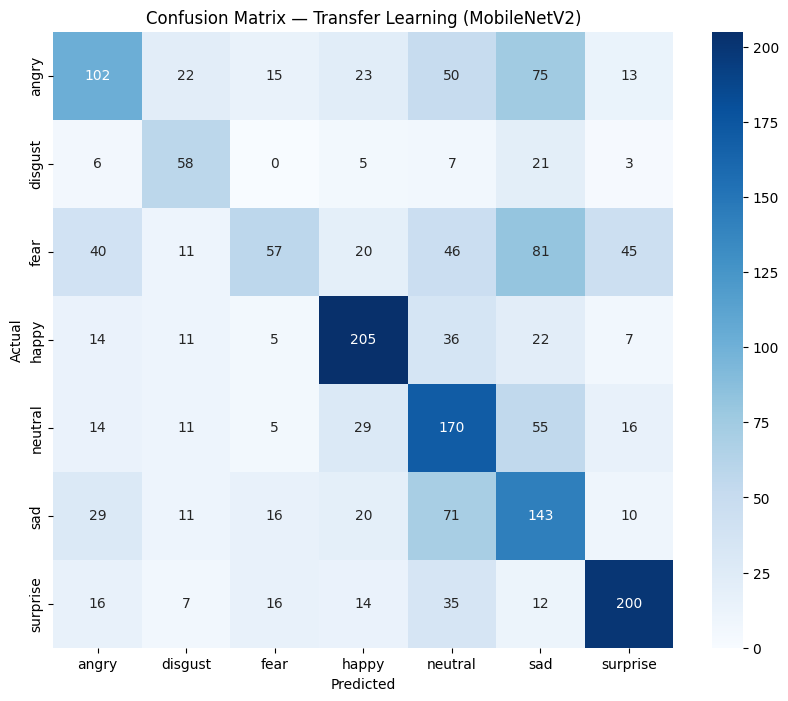

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Transfer Learning (MobileNetV2)')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


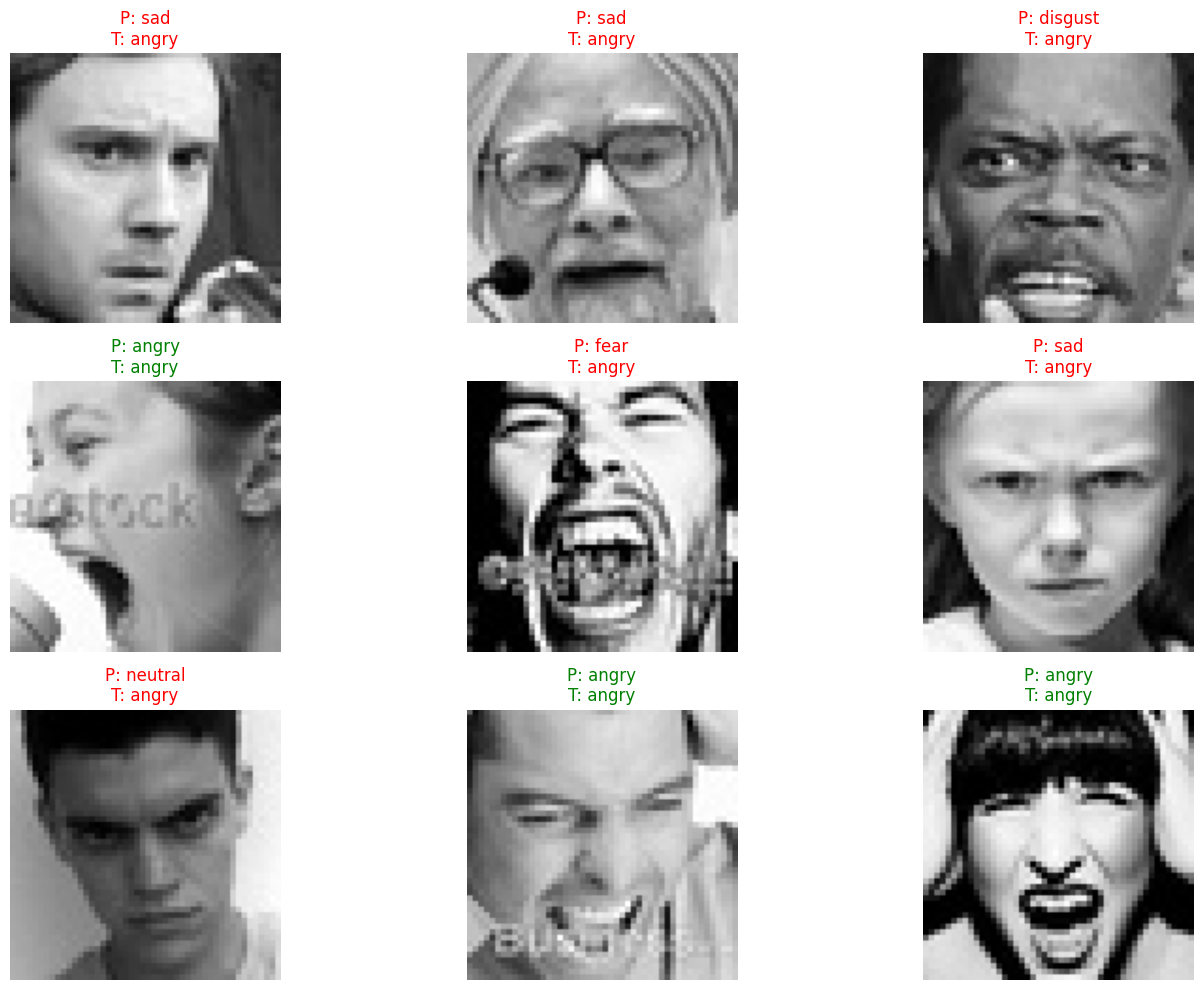

In [ ]:
sample_batch = next(test_generator)

images, labels = sample_batch

preds = transfer_model.predict(images)

pred_classes = np.argmax(preds, axis=1)

true_cls = np.argmax(labels, axis=1)

plt.figure(figsize=(15, 10))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    # show as greyscale even though model saw RGB
    plt.imshow(images[i][:, :, 0], cmap='gray')

    pred_label = class_labels[pred_classes[i]]
    true_label = class_labels[true_cls[i]]

    color = 'green' if pred_classes[i] == true_cls[i] else 'red'

    plt.title(f"P: {pred_label}\nT: {true_label}", color=color)

    plt.axis('off')

plt.tight_layout()
plt.show()